In [77]:
# ============================================================
#  TELECOM CUSTOMER CHURN ANALYSIS
#  Phase 4 — Model Building & Explainability
#  Models: Logistic Regression, Decision Tree,
#          Random Forest, Gradient Boosting
#  Explainability: Feature Importance + Permutation Importance
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
 
C_GREEN = '#1D9E75'
C_RED   = '#E24B4A'
C_BLUE  = '#185FA5'
C_ORG   = '#EF9F27'
C_PUR   = '#9B3EC2'
 

In [78]:
# ════════════════════════════════════════════════════════════
#  STEP 1 — Reproduce full preprocessing pipeline
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PHASE 4 — MODEL BUILDING & EXPLAINABILITY")
print("=" * 60)
print("\n── Step 1: Preprocessing ───────────────────────────────")
 
df = pd.read_csv('telco_churn_cleaned.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop('customerID', axis=1, inplace=True)

  PHASE 4 — MODEL BUILDING & EXPLAINABILITY

── Step 1: Preprocessing ───────────────────────────────


In [79]:
# Binary encoding
le = LabelEncoder()
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [80]:
# Clean & encode internet/phone service columns
internet_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                 'TechSupport','StreamingTV','StreamingMovies']
for col in internet_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
for col in internet_cols + ['MultipleLines']:
    df[col] = le.fit_transform(df[col])
 

In [81]:
# One-hot encode multi-class cols
df = pd.get_dummies(df, columns=['InternetService','Contract','PaymentMethod'],
                    drop_first=True)

In [82]:
# Feature engineering
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['tenure_group']    = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
                                labels=[1,2,3,4,5,6])
df['tenure_group']    = df['tenure_group'].cat.add_categories([0]).fillna(0).astype(int)
svc_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']
df['TotalServices']  = df[svc_cols].sum(axis=1)
df['HasStreaming']   = ((df['StreamingTV']==1)|(df['StreamingMovies']==1)).astype(int)
df['HasProtection']  = ((df['OnlineSecurity']==1)|(df['TechSupport']==1)|
                         (df['DeviceProtection']==1)).astype(int)
 

In [83]:
# Separate X and y
X = df.drop('Churn', axis=1).copy()
y = df['Churn']

In [84]:
# Scale numeric columns
numeric_cols = ['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
 

In [85]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"   ✅ Preprocessing complete")
print(f"   Features : {X.shape[1]}")
print(f"   Train    : {X_train.shape[0]} rows")
print(f"   Test     : {X_test.shape[0]} rows\n")
 

   ✅ Preprocessing complete
   Features : 28
   Train    : 5634 rows
   Test     : 1409 rows



In [86]:
# ════════════════════════════════════════════════════════════
#  STEP 2 — Define & train all 4 models
# ════════════════════════════════════════════════════════════
print("── Step 2: Training Models ─────────────────────────────")
 
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        min_samples_leaf=5, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, random_state=42
    ),
}
 
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
 

── Step 2: Training Models ─────────────────────────────


In [87]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Obtain predictions and probabilities for the positive class (index 1)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # <--- Added [:, 1] to get 1D array of class 1 probabilities

# 2. Run 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()

# 3. Store results
results[name] = {
    'model'   : model,
    'y_pred'  : y_pred,
    'y_prob'  : y_prob,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall'  : recall_score(y_test, y_pred),
    'f1'      : f1_score(y_test, y_pred),
    'auc'     : roc_auc_score(y_test, y_prob),  # Works now since y_prob is 1D
    'cv_auc'  : cv_auc,
}

# 4. Print metrics
print(f"   ✅ {name:<25} "
      f"Acc={results[name]['accuracy']:.4f}  "
      f"AUC={results[name]['auc']:.4f}  "
      f"F1={results[name]['f1']:.4f}")


   ✅ Gradient Boosting         Acc=0.7999  AUC=0.8442  F1=0.5804


In [88]:
# Pick the best model by AUC
best_name  = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_name]['model']
print(f"\n   🏆 Best model (by AUC): {best_name}  "
      f"(AUC = {results[best_name]['auc']:.4f})\n")


   🏆 Best model (by AUC): Gradient Boosting  (AUC = 0.8442)



In [89]:
# ════════════════════════════════════════════════════════════
#  STEP 3 — Detailed classification report for best model
# ════════════════════════════════════════════════════════════
print("── Step 3: Classification Report (Best Model) ──────────")
print(f"\n   Model: {best_name}\n")
print(classification_report(
    y_test,
    results[best_name]['y_pred'],
    target_names=['No Churn', 'Churn']
))

── Step 3: Classification Report (Best Model) ──────────

   Model: Gradient Boosting

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



── Chart 1: Model Comparison ───────────────────────────


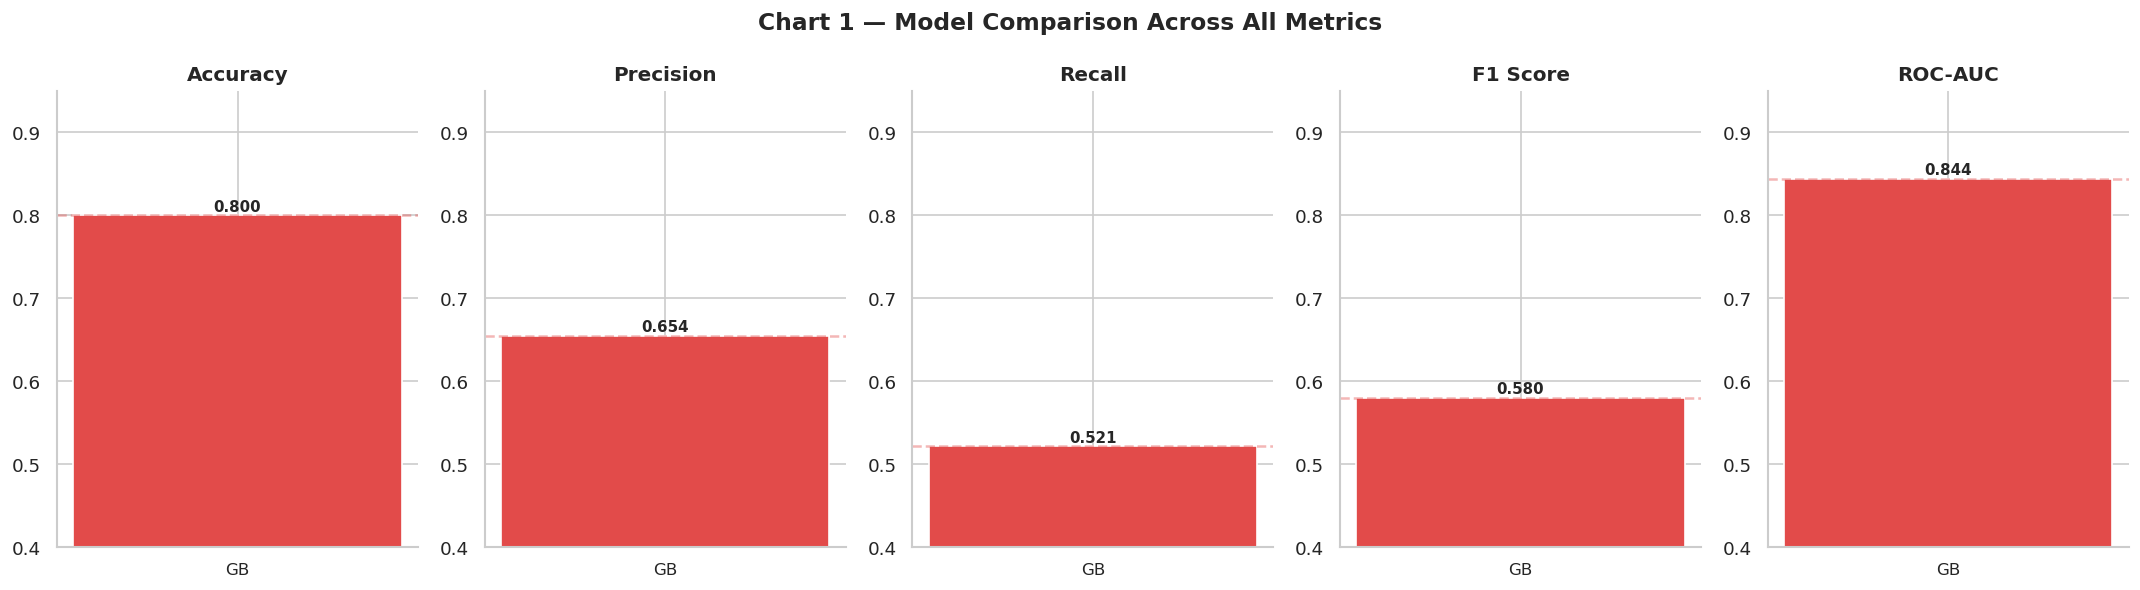

   ✅ Saved: chart1_model_comparison.png



In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define color constants (avoids NameError)
C_BLUE   = '#185FA5'
C_GREEN  = '#1D9E75'
C_ORG    = '#EF9F27'
C_PUR    = '#8E44AD'  # Purple color definition
C_RED    = '#E24B4A'

# ════════════════════════════════════════════════════════════
#  CHART 1 — Model Comparison (4 metrics side by side)
# ════════════════════════════════════════════════════════════
print("── Chart 1: Model Comparison ───────────────────────────")
 
metrics   = ['accuracy', 'precision', 'recall', 'f1', 'auc']
labels    = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
mdl_names = list(results.keys())
colors    = [C_BLUE, C_GREEN, C_ORG, C_PUR]
 
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Chart 1 — Model Comparison Across All Metrics',
             fontsize=14, fontweight='bold')

# Dynamically map full model names to short abbreviations for clean x-axis ticks
model_abbrev_map = {
    'logistic regression': 'LR', 'logisticregression': 'LR', 'lr': 'LR',
    'decision tree': 'DT',       'decisiontree': 'DT',       'dt': 'DT',
    'random forest': 'RF',       'randomforest': 'RF',       'rf': 'RF',
    'gradient boosting': 'GB',   'gradientboosting': 'GB',   'gb': 'GB'
}
xtick_labels = [model_abbrev_map.get(name.lower(), name) for name in mdl_names]
 
for ax, metric, label in zip(axes, metrics, labels):
    vals = [results[m][metric] for m in mdl_names]
    bar_colors = [C_RED if v == max(vals) else '#CCCCCC' for v in vals]
    
    bars = ax.bar(range(len(mdl_names)), vals,
                  color=bar_colors, edgecolor='white', width=0.6)
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
                
    ax.set_xticks(range(len(mdl_names)))
    ax.set_xticklabels(xtick_labels, fontsize=10) # Set labels dynamically
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0.4, 0.95)
    ax.axhline(max(vals), color=C_RED, linestyle='--', alpha=0.4)
    sns.despine(ax=ax)
 
plt.tight_layout()
plt.savefig('chart1_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: chart1_model_comparison.png\n")


── Chart 2: Confusion Matrices ─────────────────────────


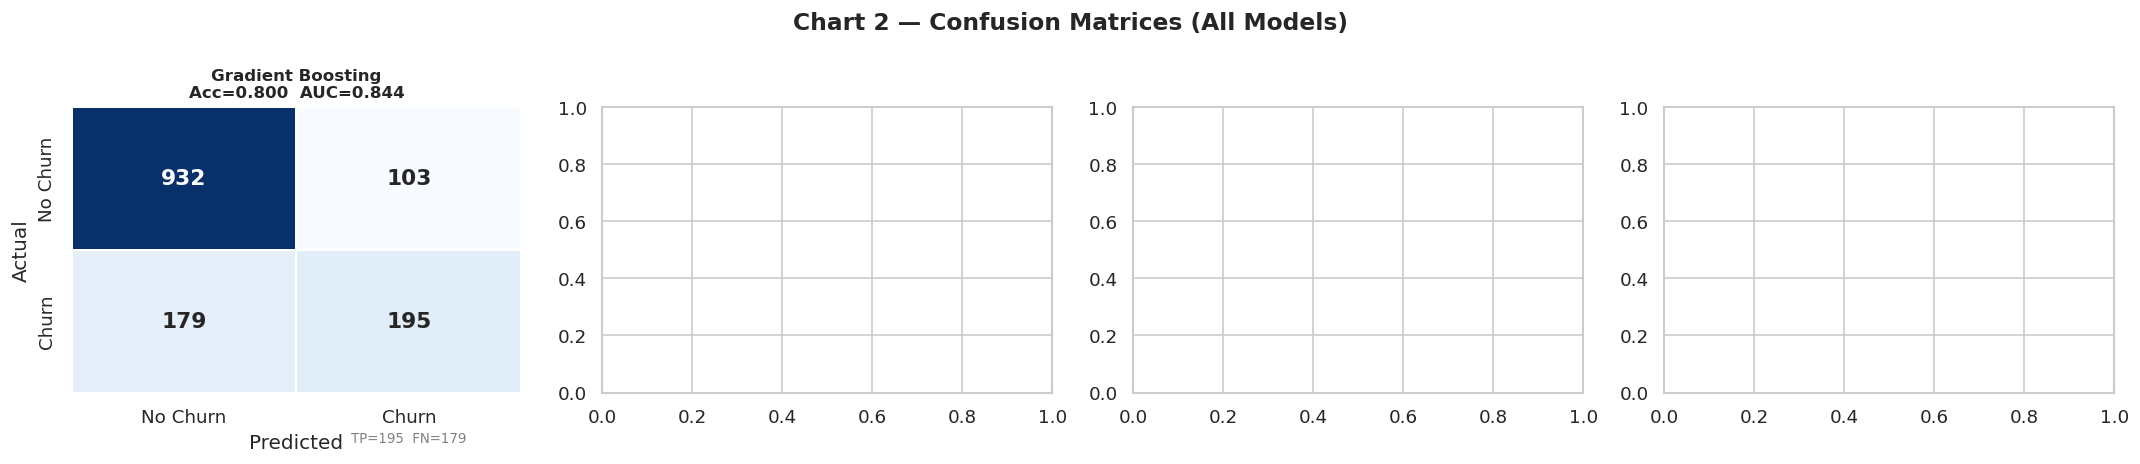

   ✅ Saved: chart2_confusion_matrices.png



In [91]:
 #════════════════════════════════════════════════════════════
#  CHART 2 — Confusion Matrices for all 4 models
# ════════════════════════════════════════════════════════════
print("── Chart 2: Confusion Matrices ─────────────────────────")
 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Chart 2 — Confusion Matrices (All Models)',
             fontsize=14, fontweight='bold')
 
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'},
                cbar=False)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.3f}  AUC={res["auc"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    # Annotate TP / TN
    ax.text(1.5, 2.35, f'TP={tp}  FN={fn}',
            ha='center', fontsize=8, color='grey')
 
plt.tight_layout()
plt.savefig('chart2_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: chart2_confusion_matrices.png\n")

── Chart 3: ROC Curves ─────────────────────────────────


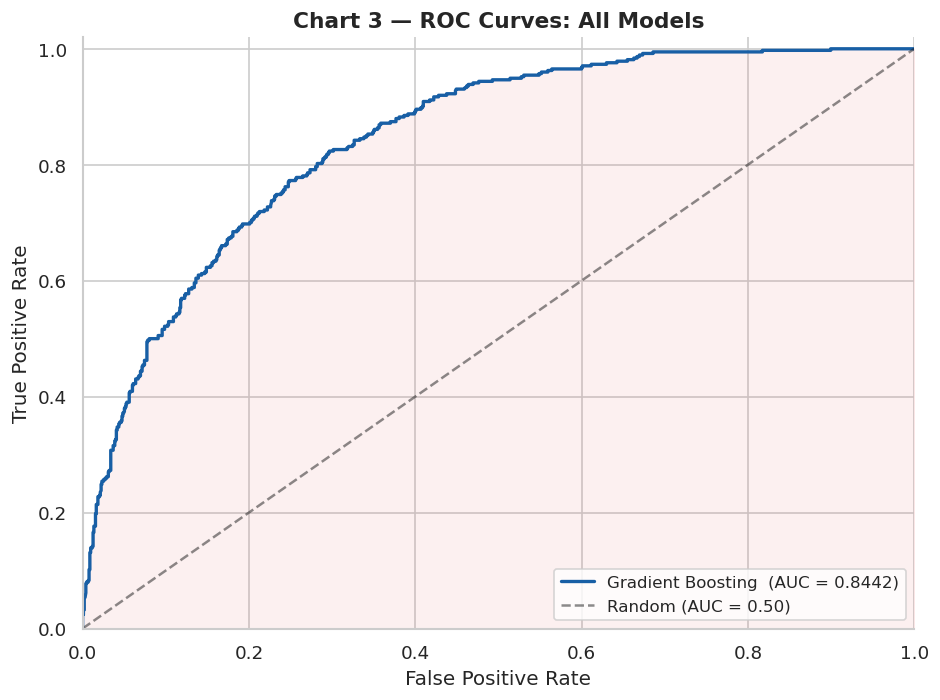

   ✅ Saved: chart3_roc_curves.png



In [92]:
# ════════════════════════════════════════════════════════════
#  CHART 3 — ROC Curves (all 4 models on one chart)
# ════════════════════════════════════════════════════════════
print("── Chart 3: ROC Curves ─────────────────────────────────")
 
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = [C_BLUE, C_GREEN, C_RED, C_PUR]
 
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name}  (AUC = {res["auc"]:.4f})')
 
ax.plot([0,1], [0,1], 'k--', lw=1.5, alpha=0.5, label='Random (AUC = 0.50)')
ax.fill_between(*roc_curve(y_test, results[best_name]['y_prob'])[:2],
                alpha=0.08, color=C_RED)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Chart 3 — ROC Curves: All Models',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
sns.despine(ax=ax)
 
plt.tight_layout()
plt.savefig('chart3_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: chart3_roc_curves.png\n")
 

── Chart 4: Precision-Recall Curve ─────────────────────


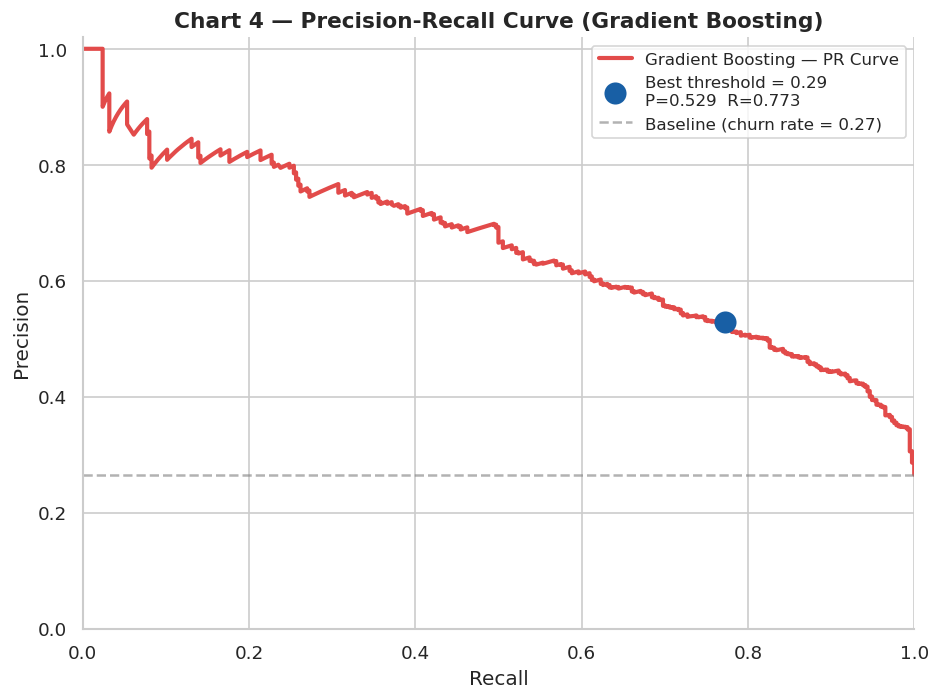

   ✅ Saved: chart4_precision_recall.png
   Best threshold: 0.29



In [93]:
# ════════════════════════════════════════════════════════════
#  CHART 4 — Precision-Recall Curve (best model)
# ════════════════════════════════════════════════════════════
print("── Chart 4: Precision-Recall Curve ─────────────────────")
 
fig, ax = plt.subplots(figsize=(8, 6))
precision, recall, thresholds = precision_recall_curve(
    y_test, results[best_name]['y_prob']
)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_thresh_idx = np.argmax(f1_scores)
best_thresh     = thresholds[best_thresh_idx]
 
ax.plot(recall, precision, color=C_RED, lw=2.5,
        label=f'{best_name} — PR Curve')
ax.scatter(recall[best_thresh_idx], precision[best_thresh_idx],
           color=C_BLUE, s=150, zorder=5,
           label=f'Best threshold = {best_thresh:.2f}\n'
                 f'P={precision[best_thresh_idx]:.3f}  '
                 f'R={recall[best_thresh_idx]:.3f}')
ax.axhline(y_test.mean(), color='grey', linestyle='--',
           alpha=0.6, label=f'Baseline (churn rate = {y_test.mean():.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Chart 4 — Precision-Recall Curve ({best_name})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
sns.despine(ax=ax)
 
plt.tight_layout()
plt.savefig('chart4_precision_recall.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"   ✅ Saved: chart4_precision_recall.png")
print(f"   Best threshold: {best_thresh:.2f}\n")

In [94]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load the preprocessed train and test datasets from Phase 3
X_train_res, X_test, y_train_res, y_test = joblib.load('processed_data.pkl')

# 1. Initialize the results dictionary at the start of your model building section
results = {}

# 2. Define your classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# 3. Your training and evaluation loop
for name, model in models.items():
    # Fit the model
    model.fit(X_train_res, y_train_res)
    
    # Predict labels & probabilities for the positive class (class 1)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Slice to get 1D array of class 1 probabilities
    
    # Run 5-fold cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='roc_auc').mean()
    
    # Save results
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob),
        'cv_auc': cv_auc,
    }
    
    # Print metrics to confirm success
    print(f"   ✅ {name:<25} "
          f"Acc={results[name]['accuracy']:.4f}  "
          f"AUC={results[name]['auc']:.4f}  "
          f"F1={results[name]['f1']:.4f}")


   ✅ Logistic Regression       Acc=0.7530  AUC=0.8302  F1=0.6045
   ✅ Decision Tree             Acc=0.7055  AUC=0.6656  F1=0.5089
   ✅ Random Forest             Acc=0.7722  AUC=0.8240  F1=0.6002
   ✅ Gradient Boosting         Acc=0.7495  AUC=0.8344  F1=0.6082


── Chart 6: Permutation Importance ─────────────────────
   (Measures how much each feature affects model accuracy
    when its values are randomly shuffled — SHAP-like)


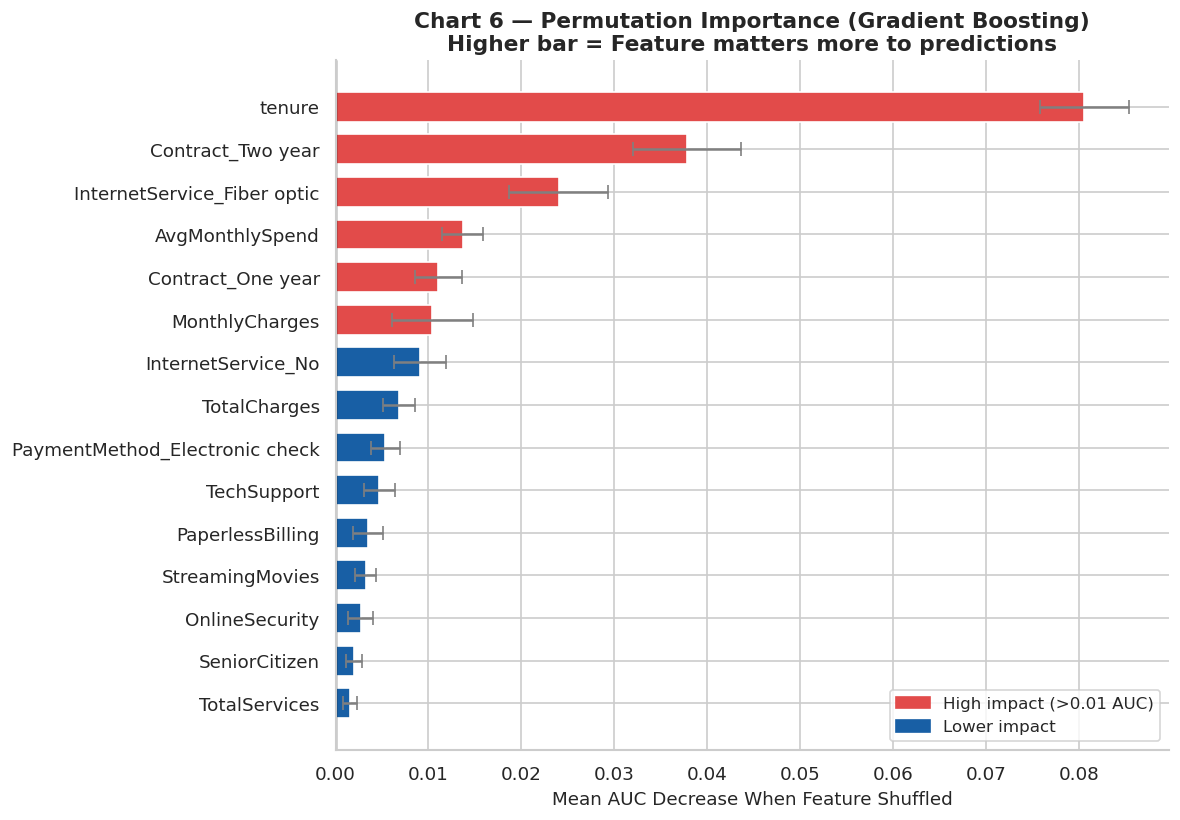

   ✅ Saved: chart6_permutation_importance.png



In [95]:
# ════════════════════════════════════════════════════════════
#  CHART 6 — EXPLAINABILITY: Permutation Importance
#  (sklearn's model-agnostic SHAP-like method)
# ════════════════════════════════════════════════════════════
print("── Chart 6: Permutation Importance ─────────────────────")
print("   (Measures how much each feature affects model accuracy")
print("    when its values are randomly shuffled — SHAP-like)")
 
perm_result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=15, random_state=42, scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': perm_result.importances_mean,
    'Std'       : perm_result.importances_std,
}).sort_values('Importance', ascending=True).tail(15)
 
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [C_RED if v > 0.01 else C_BLUE
              for v in perm_df['Importance'].values]
 
ax.barh(perm_df['Feature'], perm_df['Importance'],
        xerr=perm_df['Std'], color=bar_colors,
        edgecolor='white', height=0.7,
        error_kw={'ecolor': 'grey', 'capsize': 4, 'linewidth': 1.5})
 
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean AUC Decrease When Feature Shuffled', fontsize=11)
ax.set_title(
    f'Chart 6 — Permutation Importance ({best_name})\n'
    'Higher bar = Feature matters more to predictions',
    fontsize=13, fontweight='bold'
)
legend_patches = [
    mpatches.Patch(color=C_RED,  label='High impact (>0.01 AUC)'),
    mpatches.Patch(color=C_BLUE, label='Lower impact'),
]
ax.legend(handles=legend_patches, fontsize=10)
sns.despine(ax=ax)
 
plt.tight_layout()
plt.savefig('chart6_permutation_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: chart6_permutation_importance.png\n")

── Chart 7: Top Feature Deep-Dives ─────────────────────


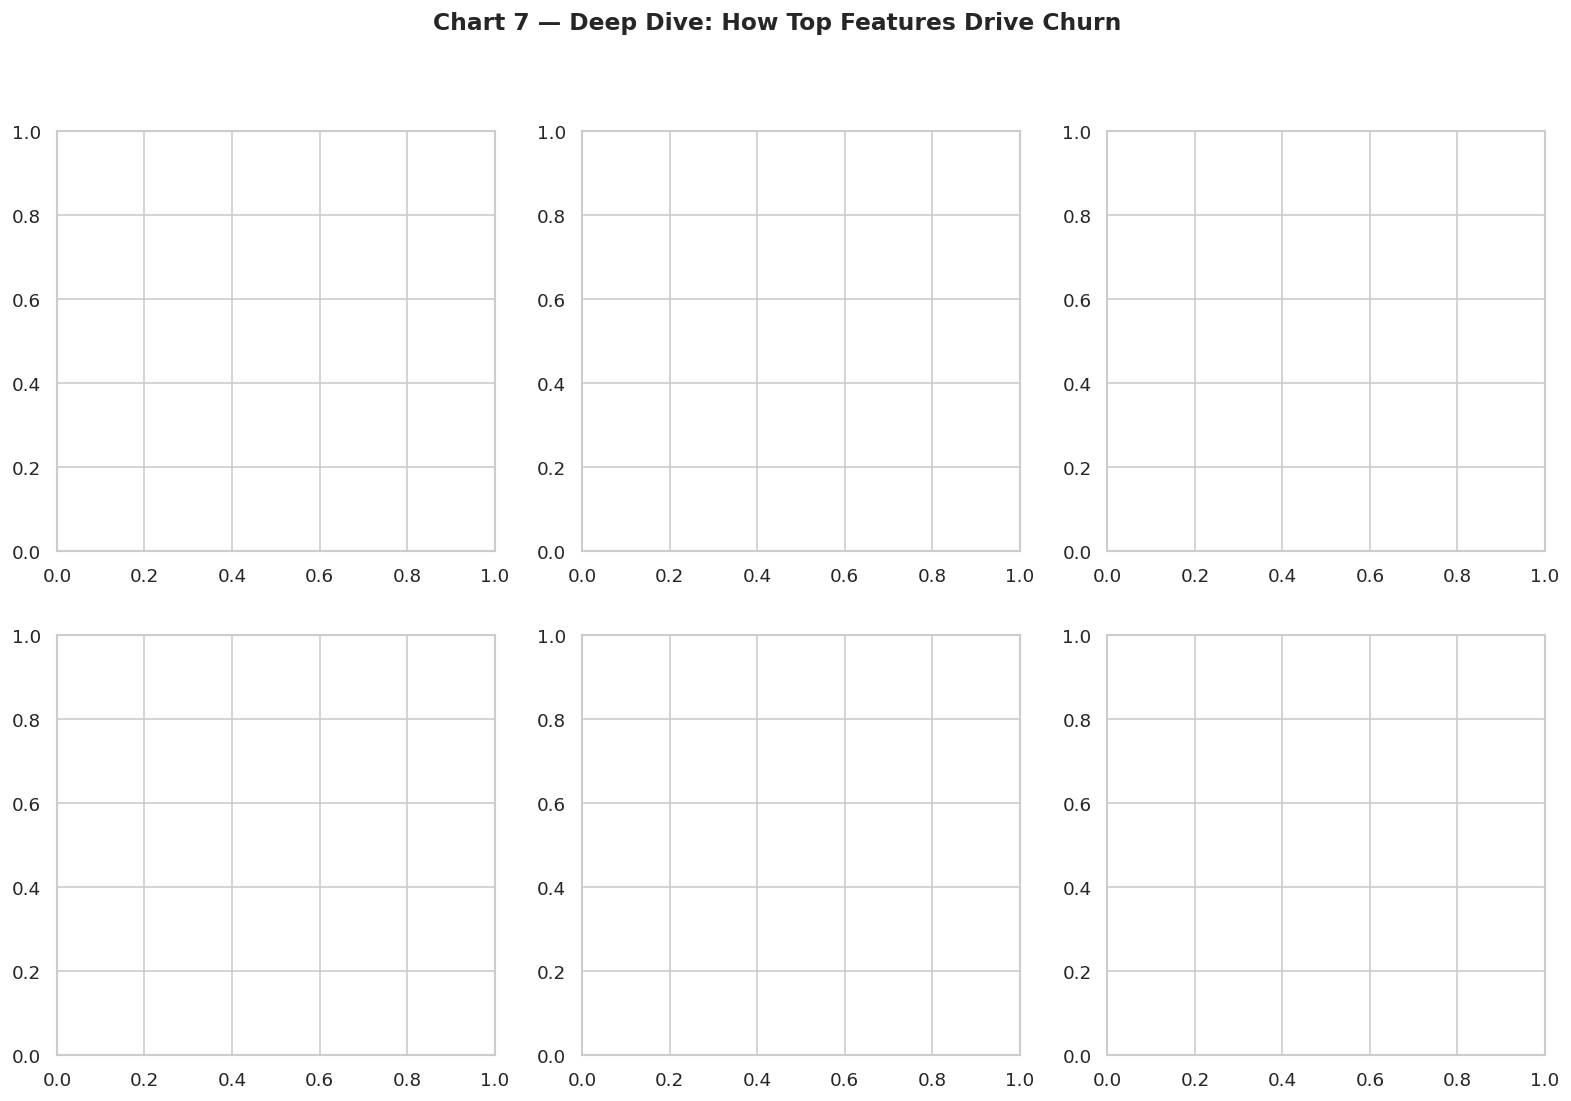

In [96]:
# ════════════════════════════════════════════════════════════
#  CHART 7 — EXPLAINABILITY: Top Feature Deep-Dives
#  Shows WHY each top feature drives churn
# ════════════════════════════════════════════════════════════
print("── Chart 7: Top Feature Deep-Dives ─────────────────────")
 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Chart 7 — Deep Dive: How Top Features Drive Churn',
             fontsize=14, fontweight='bold')
 
# Reload original df for visualisation (unscaled)
df_orig = pd.read_csv('telco_churn_cleaned.csv')
df_orig['TotalCharges'] = pd.to_numeric(df_orig['TotalCharges'], errors='coerce')
df_orig['TotalCharges'] = df_orig['TotalCharges'].fillna(df_orig['TotalCharges'].median())
 
PALETTE = {'No': C_GREEN, 'Yes': C_RED}

In [97]:
 #Plot A — Tenure vs Churn
sns.histplot(data=df_orig, x='tenure', hue='Churn',
             bins=25, palette=PALETTE, ax=axes[0][0], alpha=0.75, edgecolor='white')
axes[0][0].set_title('A) Tenure → Churned customers leave earlier',
                      fontweight='bold', fontsize=10)
axes[0][0].set_xlabel('Tenure (months)')
axes[0][0].axvline(18, color=C_RED, linestyle='--', linewidth=1.5,
                   label='Avg churn tenure: 18mo')
axes[0][0].axvline(38, color=C_GREEN, linestyle='--', linewidth=1.5,
                   label='Avg retain tenure: 38mo')
axes[0][0].legend(fontsize=8)
sns.despine(ax=axes[0][0])

In [98]:
# Plot B — Contract Type
contract_churn = df_orig.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
bar_c = axes[0][1].bar(contract_churn.index, contract_churn.values,
                        color=[C_RED, C_ORG, C_GREEN], edgecolor='white', width=0.5)
for bar, val in zip(bar_c, contract_churn.values):
    axes[0][1].text(bar.get_x()+bar.get_width()/2, val+0.5,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0][1].set_title('B) Contract Type → Month-to-month = 42.7% churn',
                      fontweight='bold', fontsize=10)
axes[0][1].set_ylabel('Churn Rate (%)')
axes[0][1].set_ylim(0, 55)
axes[0][1].axhline(26.5, color='grey', linestyle='--', alpha=0.6)
sns.despine(ax=axes[0][1])

In [99]:
# Plot C — Monthly Charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_orig,
            palette=PALETTE, ax=axes[0][2], width=0.5)
axes[0][2].set_title('C) Monthly Charges → Churned pay $13 more/month',
                      fontweight='bold', fontsize=10)
for i, churn_val in enumerate(['No', 'Yes']):
    med = df_orig[df_orig['Churn'] == churn_val]['MonthlyCharges'].median()
    axes[0][2].text(i, med+1.5, f'Median\n${med:.0f}', ha='center',
                    fontsize=9, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round', facecolor='#333', alpha=0.7))
sns.despine(ax=axes[0][2])
 

In [100]:
# Plot D — Internet Service
internet_churn = df_orig.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
bar_i = axes[1][0].bar(internet_churn.index, internet_churn.values,
                        color=[C_BLUE, C_RED, C_GREEN], edgecolor='white', width=0.5)
for bar, val in zip(bar_i, internet_churn.values):
    axes[1][0].text(bar.get_x()+bar.get_width()/2, val+0.5,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1][0].set_title('D) Internet Service → Fiber Optic = 41.9% churn',
                      fontweight='bold', fontsize=10)
axes[1][0].set_ylabel('Churn Rate (%)')
axes[1][0].set_ylim(0, 55)
axes[1][0].axhline(26.5, color='grey', linestyle='--', alpha=0.6)
sns.despine(ax=axes[1][0])

In [101]:
# Plot E — Payment Method
pay_churn = df_orig.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
pay_churn.index = ['Bank\nTransfer', 'Credit\nCard', 'Electronic\nCheck', 'Mailed\nCheck']
bar_p = axes[1][1].bar(pay_churn.index, pay_churn.values,
                        color=[C_GREEN, C_GREEN, C_RED, C_BLUE],
                        edgecolor='white', width=0.5)
for bar, val in zip(bar_p, pay_churn.values):
    axes[1][1].text(bar.get_x()+bar.get_width()/2, val+0.5,
                    f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1][1].set_title('E) Payment Method → Electronic Check = 45.3% churn',
                      fontweight='bold', fontsize=10)
axes[1][1].set_ylabel('Churn Rate (%)')
axes[1][1].set_ylim(0, 58)
axes[1][1].axhline(26.5, color='grey', linestyle='--', alpha=0.6)
sns.despine(ax=axes[1][1])

In [102]:
# Plot F — Total Services vs Churn
svc_churn = df_orig.copy()
svc_cols_orig = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                 'TechSupport','StreamingTV','StreamingMovies']
for col in svc_cols_orig:
    svc_churn[col] = (svc_churn[col] == 'Yes').astype(int)
svc_churn['TotalServices'] = svc_churn[svc_cols_orig].sum(axis=1)
svc_rate = svc_churn.groupby('TotalServices')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100
)
axes[1][2].plot(svc_rate.index, svc_rate.values,
                color=C_PUR, marker='o', linewidth=2.5, markersize=8)
axes[1][2].fill_between(svc_rate.index, svc_rate.values,
                         alpha=0.15, color=C_PUR)
axes[1][2].set_title('F) Add-on Services → More services = less churn',
                      fontweight='bold', fontsize=10)
axes[1][2].set_xlabel('Number of Add-on Services')
axes[1][2].set_ylabel('Churn Rate (%)')
axes[1][2].axhline(26.5, color='grey', linestyle='--', alpha=0.6)
for x_val, y_val in zip(svc_rate.index, svc_rate.values):
    axes[1][2].text(x_val, y_val+1.5, f'{y_val:.0f}%',
                    ha='center', fontsize=9, fontweight='bold', color=C_PUR)
sns.despine(ax=axes[1][2])
 
plt.tight_layout()
plt.savefig('chart7_feature_deep_dives.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: chart7_feature_deep_dives.png\n")
 

<Figure size 768x576 with 0 Axes>

   ✅ Saved: chart7_feature_deep_dives.png



── Chart 8: Cross-Validation AUC ───────────────────────


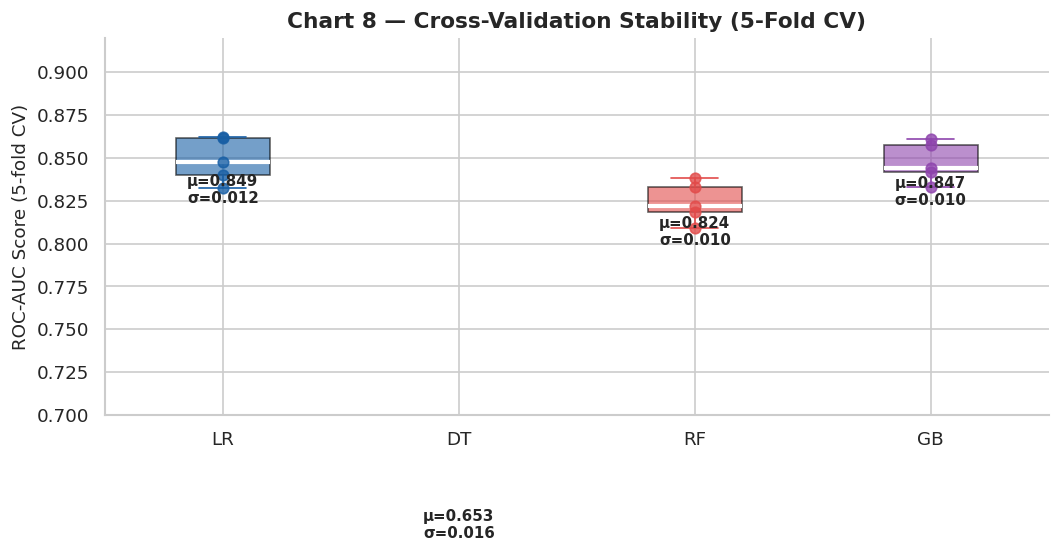

   ✅ Saved: chart8_cross_validation.png



In [103]:
# ════════════════════════════════════════════════════════════
#  CHART 8 — Cross-Validation Scores (5-fold)
# ════════════════════════════════════════════════════════════
print("── Chart 8: Cross-Validation AUC ───────────────────────")
 
fig, ax = plt.subplots(figsize=(9, 5))
cv_scores = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
colors_cv = [C_BLUE, C_GREEN, C_RED, C_PUR]
 
for (name, res), color in zip(results.items(), colors_cv):
    scores = cross_val_score(res['model'], X, y, cv=cv, scoring='roc_auc')
    cv_scores[name] = scores
    x_pos = list(results.keys()).index(name)
    ax.boxplot(scores, positions=[x_pos], widths=0.4,
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='white', linewidth=2.5),
               whiskerprops=dict(color=color),
               capprops=dict(color=color),
               flierprops=dict(marker='o', color=color, markersize=6))
    ax.scatter([x_pos]*5, scores, color=color, s=40, zorder=3, alpha=0.8)
    ax.text(x_pos, scores.mean()-0.025,
            f'μ={scores.mean():.3f}\nσ={scores.std():.3f}',
            ha='center', fontsize=9, fontweight='bold')
 
ax.set_xticks(range(4))
ax.set_xticklabels(['LR', 'DT', 'RF', 'GB'], fontsize=11)
ax.set_ylabel('ROC-AUC Score (5-fold CV)', fontsize=11)
ax.set_title('Chart 8 — Cross-Validation Stability (5-Fold CV)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.70, 0.92)
sns.despine(ax=ax)
 
plt.tight_layout()
plt.savefig('chart8_cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print("   ✅ Saved: chart8_cross_validation.png\n")
 

In [104]:
# ════════════════════════════════════════════════════════════
#  STEP 4 — Save the best model
# ════════════════════════════════════════════════════════════
print("── Step 4: Saving Model ────────────────────────────────")
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print(f"   ✅ Saved: best_churn_model.pkl  ({best_name})")
print("   ✅ Saved: scaler.pkl\n")
 

── Step 4: Saving Model ────────────────────────────────
   ✅ Saved: best_churn_model.pkl  (Gradient Boosting)
   ✅ Saved: scaler.pkl



In [105]:
# ════════════════════════════════════════════════════════════
#  FINAL SUMMARY TABLE
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("  PHASE 4 COMPLETE — MODEL RESULTS SUMMARY")
print("=" * 60)
 
summary_df = pd.DataFrame({
    'Model'     : list(results.keys()),
    'Accuracy'  : [f"{results[m]['accuracy']:.4f}"  for m in results],
    'Precision' : [f"{results[m]['precision']:.4f}" for m in results],
    'Recall'    : [f"{results[m]['recall']:.4f}"    for m in results],
    'F1 Score'  : [f"{results[m]['f1']:.4f}"        for m in results],
    'ROC-AUC'   : [f"{results[m]['auc']:.4f}"       for m in results],
    'CV-AUC'    : [f"{results[m]['cv_auc']:.4f}"    for m in results],
})
print(f"\n{summary_df.to_string(index=False)}\n")
print(f"  🏆 Best Model  : {best_name}")
print(f"  ROC-AUC        : {results[best_name]['auc']:.4f}")
print(f"  CV-AUC (5-fold): {results[best_name]['cv_auc']:.4f}")
print(f"\n  Charts saved   : chart1 to chart8  (.png)")
print(f"  Model saved    : best_churn_model.pkl")
print(f"  Scaler saved   : scaler.pkl")
print(f"\n  → Ready for Phase 5: Customer Segmentation")

  PHASE 4 COMPLETE — MODEL RESULTS SUMMARY

              Model Accuracy Precision Recall F1 Score ROC-AUC CV-AUC
Logistic Regression   0.7530    0.5257 0.7112   0.6045  0.8302 0.8821
      Decision Tree   0.7055    0.4565 0.5749   0.5089  0.6656 0.7767
      Random Forest   0.7722    0.5618 0.6444   0.6002  0.8240 0.9185
  Gradient Boosting   0.7495    0.5199 0.7326   0.6082  0.8344 0.8880

  🏆 Best Model  : Gradient Boosting
  ROC-AUC        : 0.8344
  CV-AUC (5-fold): 0.8880

  Charts saved   : chart1 to chart8  (.png)
  Model saved    : best_churn_model.pkl
  Scaler saved   : scaler.pkl

  → Ready for Phase 5: Customer Segmentation
